In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf

path_dataset = '/content/drive/MyDrive/uas ml/sukulen_augmented'
batch_size = 32
img_size = (224, 224)

# Memuat Data Training
train_dataset = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="training",
    seed=123, image_size=img_size, batch_size=batch_size
)

class_names = train_dataset.class_names

# Memuat Data Validation
val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="validation",
    seed=123, image_size=img_size, batch_size=batch_size
)

# Memecah Validation (10%) dan Testing (10%)
val_batches = tf.data.experimental.cardinality(val_test_dataset)
val_dataset = val_test_dataset.take(val_batches // 2)
test_dataset = val_test_dataset.skip(val_batches // 2)

# Optimasi prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print(f"\nDistribusi siap! Kelas: {class_names}")

Found 3100 files belonging to 2 classes.
Using 2480 files for training.
Found 3100 files belonging to 2 classes.
Using 620 files for validation.

Distribusi siap! Kelas: ['daun_bulat', 'daun_runcing']


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. Memanggil pre-trained model MobileNetV2
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

# Membekukan otak dasar (Transfer Learning)
base_model.trainable = False

# 2. Merangkai Arsitektur
model_mobilenet = models.Sequential([
    # Preprocessing bawaan MobileNetV2 (Skala pixel dari [0, 255] menjadi [-1, 1])
    layers.Rescaling(1./127.5, offset=-1),

    # Ekstraktor Fitur
    base_model,

    # Layer Perata
    layers.GlobalAveragePooling2D(),

    # Layer Mencegah Overfitting
    layers.Dropout(0.2),

    # Layer Klasifikasi Final (1 Neuron karena klasifikasi biner)
    layers.Dense(1, activation='sigmoid')
])

# 3. Kompilasi Model
model_mobilenet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Pengaturan Early Stopping
# patience=30 : Akan mentolerir penurunan performa hingga 30 epoch sebelum benar-benar dihentikan
# restore_best_weights=True : Saat berhenti, model otomatis mengambil bobot terbaik, bukan bobot di epoch terakhir yang memburuk
hentikan_awal = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

model_mobilenet.summary()

model_mobilenet.save(
    '/content/drive/MyDrive/uas ml/model_mobilenet_awal.keras'
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [ ]:
# Menentukan maksimal epoch (Early Stopping)
EPOCHS = 200

print("Memulai proses training model...\n")

# Menyimpan riwayat training ke variabel 'history' untuk visualisasi grafik nanti
history_mobilenet = model_mobilenet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[hentikan_awal]
)

Memulai proses training model...

Epoch 1/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 53s 346ms/step - accuracy: 0.5778 - loss: 0.7072 - val_accuracy: 0.5594 - val_loss: 0.7051
Epoch 2/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.6206 - loss: 0.6663 - val_accuracy: 0.6156 - val_loss: 0.6500
Epoch 3/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - accuracy: 0.6198 - loss: 0.6445 - val_accuracy: 0.7219 - val_loss: 0.5857
Epoch 4/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.6524 - loss: 0.6212 - val_accuracy: 0.6906 - val_loss: 0.5961
Epoch 5/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.6794 - loss: 0.5978 - val_accuracy: 0.7125 - val_loss: 0.5629
Epoch 6/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.6923 - loss: 0.5845 - val_accuracy: 0.7406 - val_loss: 0.5450
Epoch 7/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.7101 - loss: 0.5677 - val_accuracy: 0.7469 - val_loss: 0.5400
Epoch 8/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accur

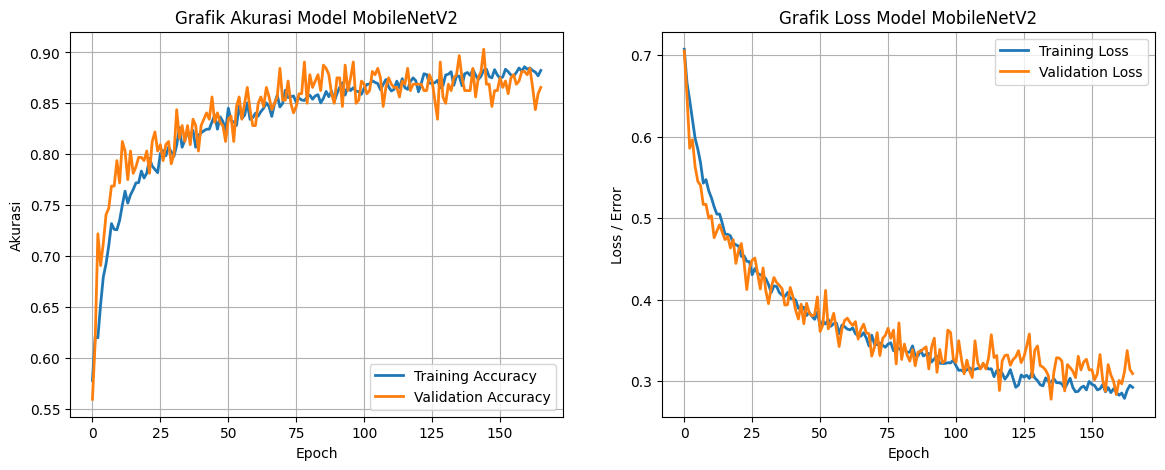

In [ ]:
import matplotlib.pyplot as plt

# Mengambil data riwayat training
acc = history_mobilenet.history['accuracy']
val_acc = history_mobilenet.history['val_accuracy']
loss = history_mobilenet.history['loss']
val_loss = history_mobilenet.history['val_loss']

# Menentukan sumbu X (jumlah epoch yang benar-benar berjalan)
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Grafik Akurasi Model MobileNetV2')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.grid(True)

# Plot Grafik Loss (Tingkat Kesalahan)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Grafik Loss Model MobileNetV2')
plt.xlabel('Epoch')
plt.ylabel('Loss / Error')
plt.grid(True)

plt.show()

--- Data Testing ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8700 - loss: 0.3393

Akurasi Testing Final: 87.00%
Loss Testing Final: 0.3393

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.84      0.87      0.85       156
daun_runcing       0.85      0.83      0.84       144

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



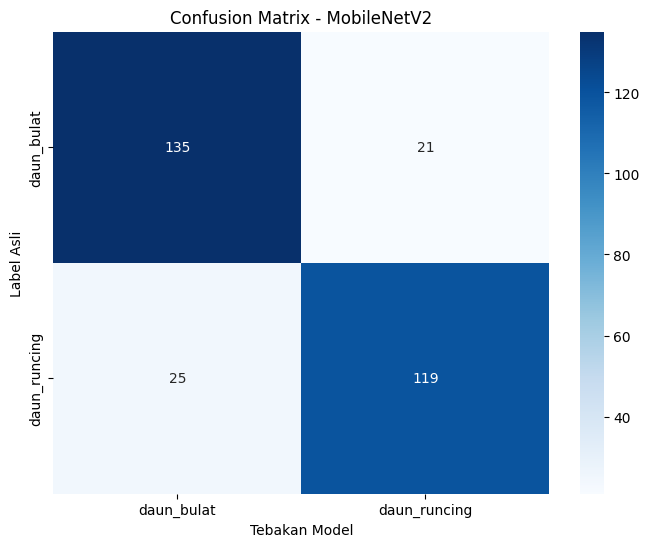

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- Data Testing ---")

# 1. Evaluasi dasar menggunakan fungsi bawaan Keras
test_loss, test_acc = model_mobilenet.evaluate(test_dataset, verbose=1)
print(f"\nAkurasi Testing Final: {test_acc * 100:.2f}%")
print(f"Loss Testing Final: {test_loss:.4f}\n")

# 2. Ekstraksi label asli dan hasil tebakan model
y_true = []
y_pred_prob = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    pred = model_mobilenet.predict(images, verbose=0)
    y_pred_prob.extend(pred)

y_true = np.array(y_true)
# Mengubah probabilitas (sigmoid) menjadi label biner (0 atau 1) dengan threshold 0.5
y_pred = np.array([1 if prob > 0.5 else 0 for prob in y_pred_prob])

# 3. Menampilkan Laporan Klasifikasi (Precision, Recall, F1-Score)
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Memvisualisasikan Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV2')
plt.ylabel('Label Asli')
plt.xlabel('Tebakan Model')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

# --- 1. MEMUAT ULANG DATASET (Agar memori Colab kembali ingat) ---
path_dataset = '/content/drive/MyDrive/uas ml/sukulen_augmented'
batch_size = 32
img_size = (224, 224)

print("--- Memuat Ulang Dataset ---")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="training",
    seed=123, image_size=img_size, batch_size=batch_size
)
val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="validation",
    seed=123, image_size=img_size, batch_size=batch_size
)

# Memecah Validation & Testing
val_batches = tf.data.experimental.cardinality(val_test_dataset)
val_dataset = val_test_dataset.take(val_batches // 2)
test_dataset = val_test_dataset.skip(val_batches // 2)

# Optimasi kecepatan baca data
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)


# --- 2. MERANGKAI MODEL SKENARIO 2 ---
# Memanggil dan membekukan base_model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model_mobilenet_eksperimen = Sequential([
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),

    # PERUBAHAN 1: Dropout dinaikkan menjadi 0.5 (50%) untuk mencegah overfitting
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# PERUBAHAN 2: Learning rate dipercepat menjadi 0.001
model_mobilenet_eksperimen.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hentikan_awal_eksperimen = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)


# --- 3. EKSEKUSI TRAINING (Target Maksimal 200 Epoch) ---
print("\nMemulai Training Skenario 2...")
history_eksperimen = model_mobilenet_eksperimen.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=200,
    callbacks=[hentikan_awal_eksperimen]
)

model_mobilenet_eksperimen.save(
    '/content/drive/MyDrive/uas ml/model_skenario_2.keras'
)

--- Memuat Ulang Dataset ---
Found 3100 files belonging to 2 classes.
Using 2480 files for training.
Found 3100 files belonging to 2 classes.
Using 620 files for validation.

Memulai Training Skenario 2...
Epoch 1/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 38s 240ms/step - accuracy: 0.5843 - loss: 0.7486 - val_accuracy: 0.6781 - val_loss: 0.5926
Epoch 2/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - accuracy: 0.6790 - loss: 0.6183 - val_accuracy: 0.7406 - val_loss: 0.4903
Epoch 3/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.7153 - loss: 0.5543 - val_accuracy: 0.8125 - val_loss: 0.4516
Epoch 4/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.7500 - loss: 0.5102 - val_accuracy: 0.8219 - val_loss: 0.4296
Epoch 5/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.7754 - loss: 0.4780 - val_accuracy: 0.8156 - val_loss: 0.4028
Epoch 6/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.7730 - loss: 0.4819 - val_accuracy: 0.7781 - val_loss: 0.4244
Epoch 7/200
78/78

In [ ]:
# --- SKENARIO 3: BATCH SIZE 64 + ADAM + LR 0.001 ---
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

# 1. Reload Data dengan Batch Size 64
path_dataset = '/content/drive/MyDrive/uas ml/sukulen_augmented'
batch_size_64 = 64
img_size = (224, 224)

print("Memuat Dataset Skenario 3 (Batch Size 64)...")
train_ds_64 = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="training",
    seed=123, image_size=img_size, batch_size=batch_size_64
)
val_test_ds_64 = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="validation",
    seed=123, image_size=img_size, batch_size=batch_size_64
)

val_batches = tf.data.experimental.cardinality(val_test_ds_64)
val_ds_64 = val_test_ds_64.take(val_batches // 2)
test_ds_64 = val_test_ds_64.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_64 = train_ds_64.prefetch(buffer_size=AUTOTUNE)
val_ds_64 = val_ds_64.prefetch(buffer_size=AUTOTUNE)

# 2. Merangkai Model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model_skenario_3 = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # Kembali ke default yang stabil
    layers.Dense(1, activation='sigmoid')
])

model_skenario_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hentikan_awal = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1)

print("\nMemulai Training Skenario 3...")
history_skenario_3 = model_skenario_3.fit(
    train_ds_64, validation_data=val_ds_64, epochs=200, callbacks=[hentikan_awal]
)

model_skenario_3.save(
    '/content/drive/MyDrive/uas ml/model_skenario_3.keras'
)

Memuat Dataset Skenario 3 (Batch Size 64)...
Found 3100 files belonging to 2 classes.
Using 2480 files for training.
Found 3100 files belonging to 2 classes.
Using 620 files for validation.

Memulai Training Skenario 3...
Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 54s 693ms/step - accuracy: 0.5536 - loss: 0.7663 - val_accuracy: 0.6187 - val_loss: 0.6632
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - accuracy: 0.6770 - loss: 0.6014 - val_accuracy: 0.6812 - val_loss: 0.5698
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - accuracy: 0.7169 - loss: 0.5458 - val_accuracy: 0.7937 - val_loss: 0.4811
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - accuracy: 0.7492 - loss: 0.5069 - val_accuracy: 0.7937 - val_loss: 0.4670
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step - accuracy: 0.7653 - loss: 0.4851 - val_accuracy: 0.7750 - val_loss: 0.4756
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - accuracy: 0.7835 - loss: 0.4592 - val_accuracy: 0.8219 - val_loss: 0.4255
Epo

In [ ]:
# --- SKENARIO 4: PEMBUKTIAN OPTIMIZER SGD ---
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# MEMUAT DATA
path_dataset = '/content/drive/MyDrive/uas ml/sukulen_augmented'
batch_size = 32
img_size = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="training",
    seed=123, image_size=img_size, batch_size=batch_size
)
val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    path_dataset, validation_split=0.2, subset="validation",
    seed=123, image_size=img_size, batch_size=batch_size
)

# Pecah jadi Validation
val_batches = tf.data.experimental.cardinality(val_test_dataset)
val_dataset = val_test_dataset.take(val_batches // 2)

# Optimasi Prefetch (Penting agar val_accuracy muncul!)
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

# DEFINISI MODEL
base_model_4 = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model_4.trainable = False

model_skenario_4 = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1),
    base_model_4,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# KOMPILASI
model_skenario_4.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# CALLBACK
hentikan_awal = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

# TRAINING (Sekarang pasti muncul val_accuracy dan val_loss)
print("\nMemulai Training Skenario 4 (Optimizer SGD)...")
history_skenario_4 = model_skenario_4.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=200,
    callbacks=[hentikan_awal]
)
# Pastikan train_dataset dan val_dataset dari batch 32 masih ada di memori Colab
base_model_4 = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model_4.trainable = False

model_skenario_4 = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1),
    base_model_4,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# Menggunakan Optimizer SGD dengan sedikit momentum
model_skenario_4.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nMemulai Training Skenario 4 (Optimizer SGD)...")
history_skenario_4 = model_skenario_4.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=200,
    callbacks=[hentikan_awal]
)

model_skenario_4.save(
    '/content/drive/MyDrive/uas ml/model_skenario_4.keras'
)

Found 3100 files belonging to 2 classes.
Using 2480 files for training.
Found 3100 files belonging to 2 classes.
Using 620 files for validation.

Memulai Training Skenario 4 (Optimizer SGD)...
Epoch 1/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 35s 218ms/step - accuracy: 0.5931 - loss: 0.6809 - val_accuracy: 0.7531 - val_loss: 0.5456
Epoch 2/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.7121 - loss: 0.5684 - val_accuracy: 0.7937 - val_loss: 0.4823
Epoch 3/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.7524 - loss: 0.5036 - val_accuracy: 0.8313 - val_loss: 0.4297
Epoch 4/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.7831 - loss: 0.4695 - val_accuracy: 0.8188 - val_loss: 0.4209
Epoch 5/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.7923 - loss: 0.4572 - val_accuracy: 0.8062 - val_loss: 0.4110
Epoch 6/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.7931 - loss: 0.4374 - val_accuracy: 0.7937 - val_loss: 0.4059
Epoch 7/200
78/78 ━━━━━━━━━━━━

Memuat ulang dataset testing ke memori...
Found 3100 files belonging to 2 classes.
Using 620 files for validation.
Dataset Testing siap!


EVALUASI FINAL: MobileNetV2 Skenario 2


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Akurasi Testing: 87.67%
Loss Testing: 0.3251

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.89      0.90      0.89       158
daun_runcing       0.89      0.87      0.88       142

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



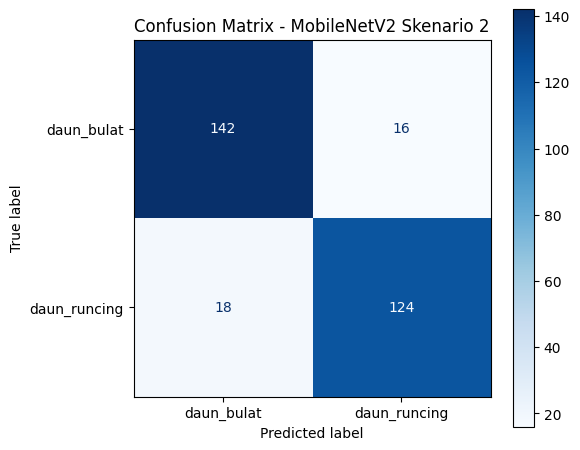


EVALUASI FINAL: MobileNetV2 Skenario 3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Akurasi Testing: 91.00%
Loss Testing: 0.2436

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.89      0.94      0.91       154
daun_runcing       0.93      0.88      0.90       146

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



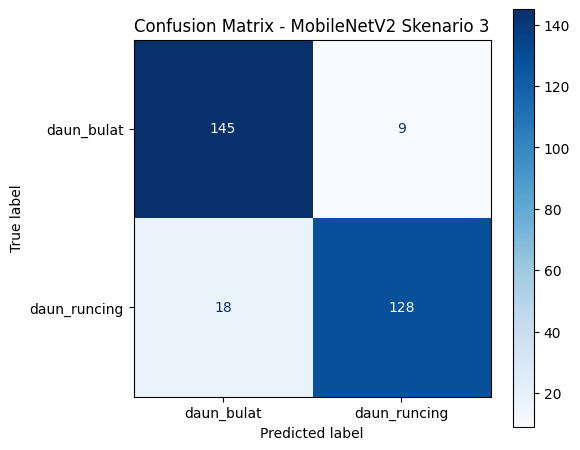


EVALUASI FINAL: MobileNetV2 Skenario 4


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Akurasi Testing: 70.00%
Loss Testing: 0.5868

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  daun_bulat       0.75      0.70      0.73       147
daun_runcing       0.73      0.78      0.75       153

    accuracy                           0.74       300
   macro avg       0.74      0.74      0.74       300
weighted avg       0.74      0.74      0.74       300



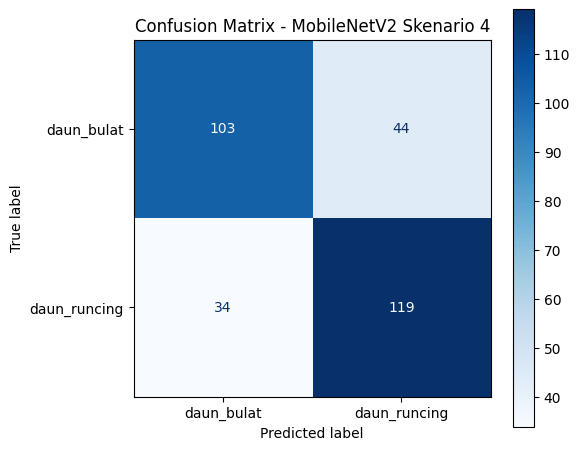

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from tensorflow.keras.models import load_model

def evaluasi_model_final(model, test_data, nama_skenario):
    print(f"\n{'='*60}")
    print(f"EVALUASI FINAL: {nama_skenario}")
    print(f"{'='*60}")

    # 1. Testing Bawaan Keras
    loss, acc = model.evaluate(test_data, verbose=0)
    print(f"Akurasi Testing: {acc * 100:.2f}%")
    print(f"Loss Testing: {loss:.4f}\n")

    # 2. Prediksi (PERBAIKAN: Sekali Jalan agar tidak tertukar)
    y_true = []
    y_pred_prob = []

    # Mengekstrak gambar dan label secara bersamaan per batch
    for images, labels in test_data:
        y_true.extend(labels.numpy())
        preds = model.predict_on_batch(images) # Prediksi gambar pada batch yang sama
        y_pred_prob.extend(preds)

    y_true = np.array(y_true)
    y_pred = (np.array(y_pred_prob) > 0.5).astype("int32")

    # 3. Classification Report
    print("=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=['daun_bulat', 'daun_runcing']
    ))

    # 4. Confusion Matrix (Menggunakan Display Scikit-Learn agar angka tidak terpotong)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['daun_bulat', 'daun_runcing'])

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f'Confusion Matrix - {nama_skenario}')
    plt.tight_layout()
    plt.show()

# ==================================================
# 1. LOAD MODEL YANG SUDAH DISIMPAN (GOOGLE DRIVE)
# ==================================================
from tensorflow.keras.models import load_model
import tensorflow as tf

# Pastikan Anda sudah menjalankan drive.mount('/content/drive') sebelumnya
path_mobilenet_2 = '/content/drive/MyDrive/uas ml/model_skenario_2.keras'
path_mobilenet_3 = '/content/drive/MyDrive/uas ml/model_skenario_3.keras'
path_mobilenet_4 = '/content/drive/MyDrive/uas ml/model_skenario_4.keras'

model_skenario_2 = load_model(path_mobilenet_2)
model_skenario_3 = load_model(path_mobilenet_3)
model_skenario_4 = load_model(path_mobilenet_4)

# ==================================================
# 2. LOAD DATASET TESTING KE MEMORI COLAB
# ==================================================
print("Memuat ulang dataset testing ke memori...")

# PERBAIKAN: Path ini sudah persis seperti di Colab Anda (tanpa folder 'dataset/')
path_dataset_colab = '/content/drive/MyDrive/uas ml/sukulen_augmented'

batch_size = 32
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    path_dataset_colab,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=batch_size
)

# Memecah sisa data menjadi Testing
val_batches = len(val_test_ds)
val_test_ds = val_test_ds.unbatch().shuffle(1000, seed=123).batch(batch_size)
test_ds_final = val_test_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
test_ds_final = test_ds_final.prefetch(buffer_size=AUTOTUNE)
print("Dataset Testing siap!\n")

# ==================================================
# 3. PANGGIL FUNGSI EVALUASI
# ==================================================

evaluasi_model_final(
    model_skenario_2,
    test_ds_final,
    "MobileNetV2 Skenario 2"
)

evaluasi_model_final(
    model_skenario_3,
    test_ds_final,
    "MobileNetV2 Skenario 3"
)

evaluasi_model_final(
    model_skenario_4,
    test_ds_final,
    "MobileNetV2 Skenario 4"
)